<a href="https://colab.research.google.com/github/turtul17/tyttt/blob/main/OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# experiment num first

In [ ]:
#Image acquisition, sampling, quantization + smoothing, sharpening, edge detection, morphology using OpenCV

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
print(cv2.__version__)

4.13.0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bird.webp to bird.webp


In [ ]:
import os

In [ ]:
os.rename('pesrson.jpeg', 'person.jpeg')


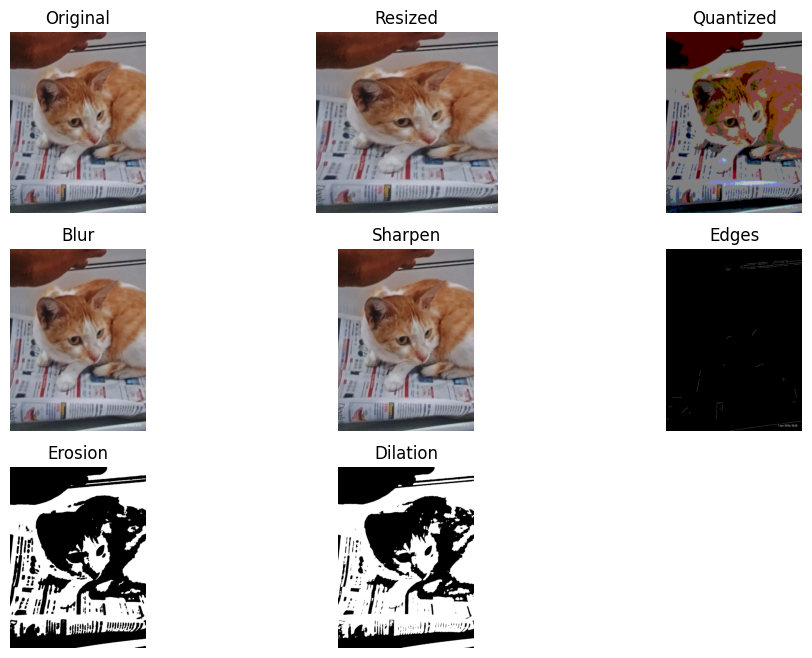

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image
img = cv2.imread('cat.jpeg')

if img is None:
    print("Image not found!")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1. Sampling
    resized = cv2.resize(img, (300, 300))

    # 2. Quantization
    quantized = (img // 64) * 64

    # 3. Smoothing
    blur = cv2.GaussianBlur(img, (5,5), 0)

    # 4. Sharpening
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    sharpen = cv2.filter2D(img, -1, kernel)

    # 5. Edge Detection
    edges = cv2.Canny(img, 100, 200)

    # 6. Morphology
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5,5), np.uint8)

    erosion = cv2.erode(thresh, kernel, 1)
    dilation = cv2.dilate(thresh, kernel, 1)

    # Display
    titles = ['Original','Resized','Quantized','Blur','Sharpen','Edges','Erosion','Dilation']
    images = [img_rgb,
              cv2.cvtColor(resized, cv2.COLOR_BGR2RGB),
              cv2.cvtColor(quantized, cv2.COLOR_BGR2RGB),
              cv2.cvtColor(blur, cv2.COLOR_BGR2RGB),
              cv2.cvtColor(sharpen, cv2.COLOR_BGR2RGB),
              edges, erosion, dilation]

    plt.figure(figsize=(12,8))
    for i in range(len(images)):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.show()